In [1]:
import scanpy as sc

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import anndata as ad

In [3]:
import pandas as pd 
import numpy as np

In [19]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [4]:
cd34 = sc.read_h5ad(
    'tripso_reproducibility/04.5_HSC_post_qc/data/raw/CD34_RNA_98266cells_to_share.h5ad'
)


In [5]:
cd34.X = cd34.layers['log_counts']

In [6]:

cd34.obs['donor'] = cd34.obs['donor_tissue'].str.extract(r'^([^_]+)_')


# update obs to match Tomo
cd34.obs['tissue'] = np.where(
    cd34.obs['tissue'] == 'EL',
    'FL', 
    cd34.obs['tissue']
)

# separate young and aged in adult BM
# categorise age groups { end with PCW : 'Fetal, 0-15: Pediatric, 16-30 : Young Adult, 31-50:  Middle Age, 50+: Aged}
cd34.obs['age_group'] = None
cd34.obs.loc[(cd34.obs['age'].str.contains('PCW')) , 'age_group'] = 'Fetal'
cd34.obs.loc[(cd34.obs['age']=='0') , 'age_group'] = 'Cord Blood'
# replace all PCW rows with empty string, e.g. 14PCW -> ''
cd34.obs['age'] = cd34.obs['age'].str.replace(r'\d+PCW', '', regex=True)
cd34.obs['age'] = cd34.obs['age'].replace('', np.nan)
cd34.obs['age'] = cd34.obs['age'].astype(float)

# distinguish between aged bone marrow Aged (60+) and young (<60)
cd34.obs['tissue'] = pd.Categorical(cd34.obs['tissue'])
cd34.obs['tissue'] = cd34.obs['tissue'].cat.add_categories(['ABM_+60y', 'ABM_29-50y']) # 'PBM'
cd34.obs.loc[cd34.obs['age'] >= 60, 'tissue'] = 'ABM_+60y'
cd34.obs.loc[(cd34.obs['age'] < 60) & (cd34.obs['age'] >= 17), 'tissue'] = 'ABM_29-50y'
cd34.obs.loc[(cd34.obs['age'] < 17) & (cd34.obs['age'] >= 1), 'tissue'] = 'PBM'

cd34.obs['tissue'] = cd34.obs['tissue'].cat.remove_unused_categories()


cd34.obs['tissue'] = cd34.obs['tissue'].cat.reorder_categories(
    ['YS', 'FL', 'FBM', 'CB', 'PBM', 'ABM_29-50y', 'ABM_+60y']
    )


In [7]:
progeny = pd.read_csv('tripso_reproducibility/02.1_benchmarking_repeat/gpdb_progeny_200.csv')

In [8]:
# sc.pl.dotplot(
#     cd34,
#     [g for g in progeny['JAK-STAT'] if g in cd34.var_names],
#     groupby = 'tissue', 
#     standard_scale = 'var',
# )

In [9]:
# https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_INTERFERON_ALPHA_RESPONSE.html
hallmark_ifna = [
    "ADAR", "B2M", "BATF2", "BST2", "C1S", "CASP1", "CASP8", "CCRL2", "CD47",
    "CD74", "CMPK2", "CNP", "CSF1", "CXCL10", "CXCL11", "DDX60", "DHX58",
    "EIF2AK2", "ELF1", "EPSTI1", "MVB12A", "TENT5A", "CMTR1", "GBP2", "GBP4",
    "GMPR", "HERC6", "HLA-C", "IFI27", "IFI30", "IFI35", "IFI44", "IFI44L",
    "IFIH1", "IFIT2", "IFIT3", "IFITM1", "IFITM2", "IFITM3", "IL15", "IL4R",
    "IL7", "IRF1", "IRF2", "IRF7", "IRF9", "ISG15", "ISG20", "LAMP3", "LAP3",
    "LGALS3BP", "LPAR6", "LY6E", "MOV10", "MX1", "NCOA7", "NMI", "NUB1",
    "OAS1", "OASL", "OGFR", "PARP12", "PARP14", "PARP9", "PLSCR1", "PNPT1",
    "HELZ2", "PROCR", "PSMA3", "PSMB8", "PSMB9", "PSME1", "PSME2", "RIPK2",
    "RNF31", "RSAD2", "RTP4", "SAMD9", "SAMD9L", "SELL", "SLC25A28", "SP110",
    "STAT2", "TAP1", "TDRD7", "TMEM140", "TRAFD1", "TRIM14", "TRIM21",
    "TRIM25", "TRIM26", "TRIM5", "TXNIP", "UBA7", "UBE2L6", "USP18", "WARS1"
]

genes_to_plot = [g for g in progeny['JAK-STAT'] if g in cd34.var_names]
genes_to_plot2 = [f"{g} *" if g in hallmark_ifna else g for g in genes_to_plot]

In [10]:
cd34.var['gene_symbol'] = cd34.var.index.tolist()

cd34.var['ifna_label'] = np.where(
    cd34.var.index.isin(hallmark_ifna),
    ' *', 
    ''
)

In [11]:
cd34.var['ifna_label'].value_counts()

ifna_label
      36505
 *       96
Name: count, dtype: int64

In [12]:
cd34.var['annotated'] = cd34.var['gene_symbol'].astype(str) + cd34.var['ifna_label'].astype(str)

In [13]:
cd34[:, cd34.var['annotated'].str.contains('STAT2')].var.head()

,gene_ids,feature_types,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,mean,std,gene_symbol,ifna_label,annotated
STAT2,ENSG00000170581,Gene Expression,False,17172,0.200065,0.182376,83.077939,20302.0,9.918524,False,NaN,0.200065,0.233871,0.869398,0,4.857971e-11,0.278671,STAT2,*,STAT2 *


In [14]:
'B2M *' in cd34.var_names

False

In [15]:
cd34.var = cd34.var.set_index('annotated')

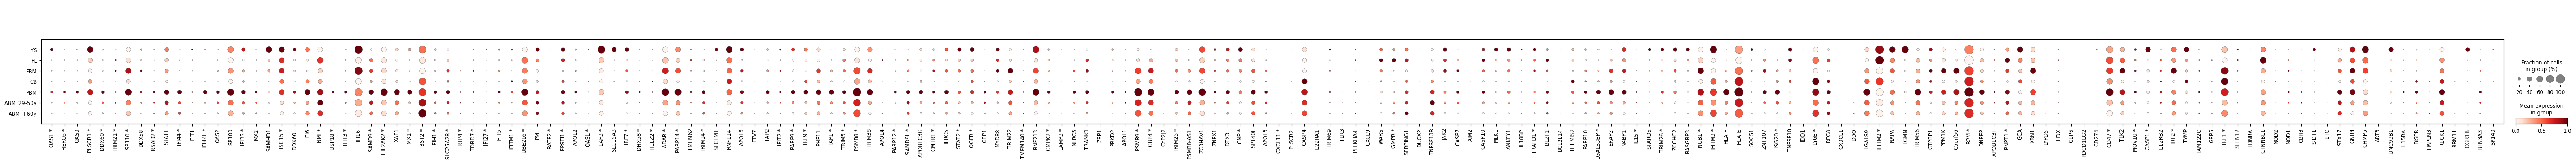

In [16]:
sc.pl.dotplot(
    cd34,
    genes_to_plot2,
    groupby = 'tissue', 
    standard_scale = 'var',
)

    

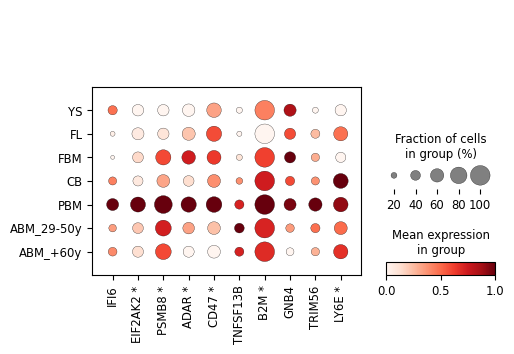

In [20]:
top10 = ['IFI6',
 'EIF2AK2',
 'PSMB8',
 'ADAR',
 'CD47',
 'TNFSF13B',
 'B2M',
 'GNB4',
 'TRIM56',
 'LY6E']

sc.pl.dotplot(
    cd34,
     [f"{g} *" if g in hallmark_ifna else g for g in top10],
    groupby = 'tissue', 
    standard_scale = 'var',
    save = 'gene_importance_top10.pdf'
)

    

In [10]:
cd34.obs['celltype_v2'].cat.categories

Index(['1_LT-HSC', '2_ST-HSC', '3_MPP', '4_MEMP', '5_MK', '6_Early_Ery',
       '7_Late_Ery', '8_BaEoMa', '9_LMPP', '10_CLP', '11_PreProB', '12_Pro_B',
       '13_Cycling_Pro_B', '14_Large_Pre_B', '15_Small_Pre_B', '16_Immature_B',
       '17_T_NK_prog', '18_CD4_T', '19_CD8_T', '20_NK', '21_GMP', '22_pDC',
       '23_DC_pre', '24_Mono_pre', '25_Macrophage'],
      dtype='object')

In [12]:
ct_to_lineage = {
    '1_LT-HSC' : 'HSPC', 
    '2_ST-HSC' : 'HSPC', 
    '3_MPP' : 'HSPC', 
    '4_MEMP' : 'Erythroid/Mk', 
    '5_MK': 'Erythroid/Mk', 
    '6_Early_Ery' : 'Erythroid/Mk',
    '7_Late_Ery': 'Erythroid/Mk', 
    '8_BaEoMa' : 'Granulo/myeloid', 
    '9_LMPP' : 'Lymphoid', 
    '10_CLP' : 'Lymphoid', 
    '11_PreProB' : 'Lymphoid', 
    '12_Pro_B'  : 'Lymphoid',
    '13_Cycling_Pro_B'  : 'Lymphoid', 
    '14_Large_Pre_B'  : 'Lymphoid', 
    '15_Small_Pre_B' : 'Lymphoid', 
    '16_Immature_B' : 'Lymphoid',
    '17_T_NK_prog'  : 'Lymphoid', 
    '18_CD4_T' : 'Lymphoid', 
    '19_CD8_T' : 'Lymphoid', 
    '20_NK' : 'Lymphoid', 
    '21_GMP' : 'Granulo/myeloid',
    '22_pDC' : 'Granulo/myeloid',
    '23_DC_pre' : 'Granulo/myeloid', 
    '24_Mono_pre'  : 'Granulo/myeloid', 
    '25_Macrophage'  : 'Granulo/myeloid'
}

In [14]:
cd34.obs['lineage'] = cd34.obs['celltype_v2'].map(ct_to_lineage)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


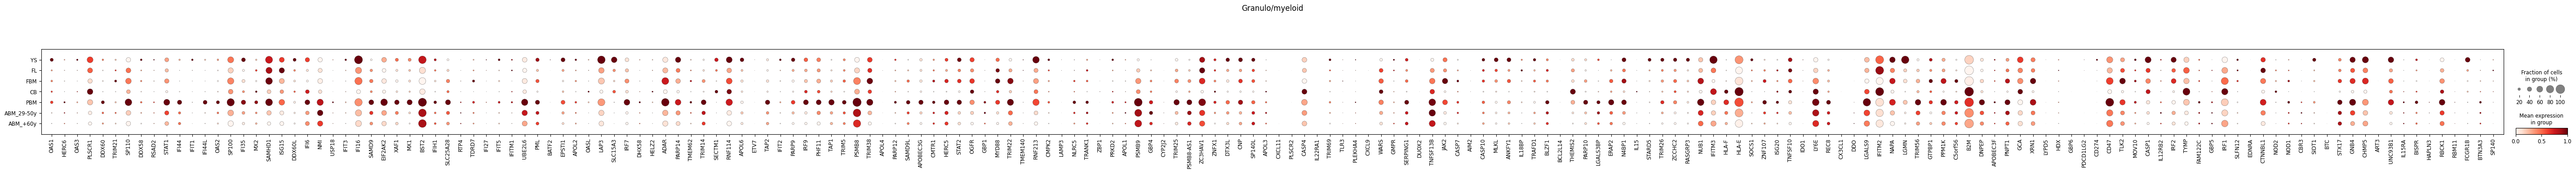

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


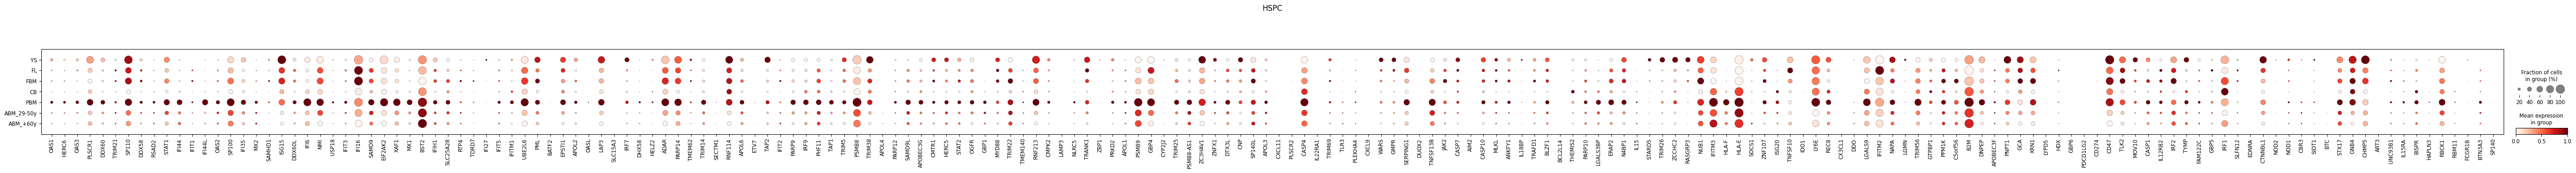

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


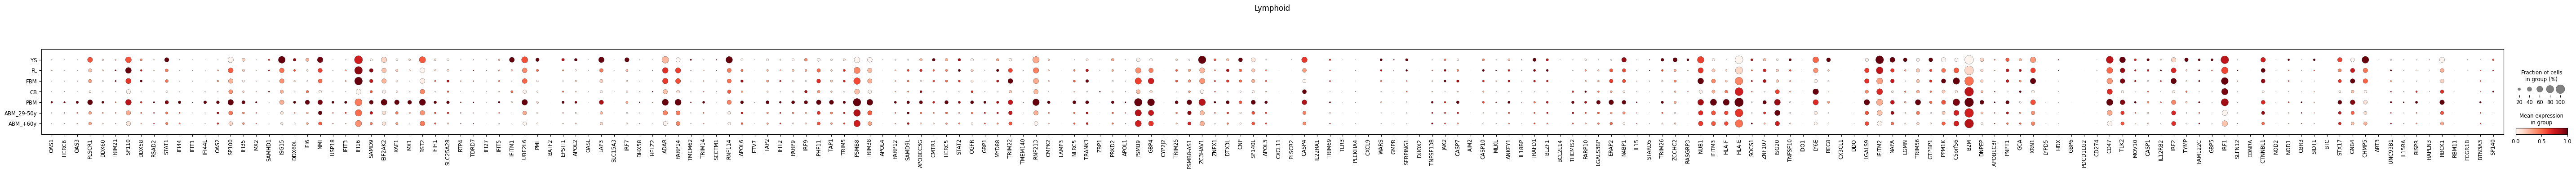

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


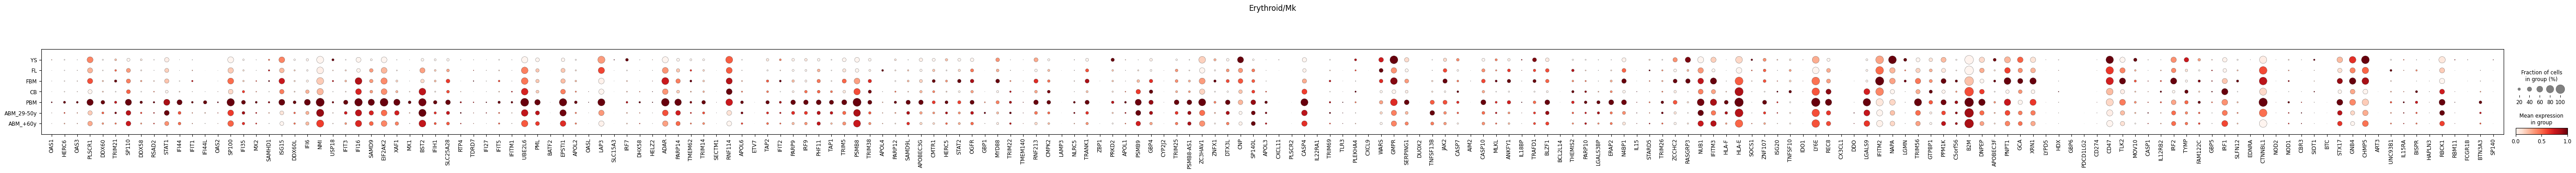

In [15]:
for t in cd34.obs['lineage'].unique():
    sc.pl.dotplot(
        cd34[cd34.obs['lineage'] == t],
        [g for g in progeny['JAK-STAT'] if g in cd34.var_names],
        groupby = 'tissue', 
        standard_scale = 'var',
        title = t
)

# Same for GP importance score

In [21]:
def get_path(training_split, run, output_name = 'global'):
    base_path = 'tripso_reproducibility/04.5_HSC_post_qc'
    return f'{base_path}/{run}_by_study/output_{output_name}/ablation/with_gp_ablation/{training_split}_set.h5ad'

In [22]:
import anndata as ad

In [23]:
train1 = sc.read_h5ad(get_path('train', 'run_1'))
train1 = train1[train1.obs['study'] == 'Isobe_CD34']

val1 = sc.read_h5ad(get_path('val', 'run_1'))
val1 = val1[val1.obs['study'] == 'Isobe_CD34']

test1 = sc.read_h5ad(get_path('test', 'run_1'))
test1 = test1[test1.obs['study'] == 'Isobe_CD34']

pert_data1 = ad.concat([train1, val1, test1])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [24]:
train2 = sc.read_h5ad(get_path('train', 'run_2'))
train2 = train2[train2.obs['study'] == 'Isobe_CD34']

val2 = sc.read_h5ad(get_path('val', 'run_2'))
val2 = val2[val2.obs['study'] == 'Isobe_CD34']

test2 = sc.read_h5ad(get_path('test', 'run_2'))
test2 = test2[test2.obs['study'] == 'Isobe_CD34']

pert_data2 = ad.concat([train2, val2, test2])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [25]:
train3 = sc.read_h5ad(get_path('train', 'run_3'))
train3 = train3[train3.obs['study'] == 'Isobe_CD34']

val3 = sc.read_h5ad(get_path('val', 'run_3'))
val3 = val3[val3.obs['study'] == 'Isobe_CD34']

test3 = sc.read_h5ad(get_path('test', 'run_3'))
test3 = test3[test3.obs['study'] == 'Isobe_CD34']

pert_data3 = ad.concat([train3, val3, test3])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [26]:
pert_data = sc.AnnData(
    X = (pert_data1.X + pert_data2.X + pert_data3.X)/3,
    obs = pert_data1.obs,
    var = pert_data1.var
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [27]:
pert_data

AnnData object with n_obs × n_vars = 98266 × 45
    obs: 'length', 'scaled_length', 'runid_mrna_sample', 'age', 'sorting', 'sex', 'tissue', 'age_general', 'phase', 'S_score', 'G2M_score', 'leiden', 'cell_type', 'donor_tissue', 'source', 'tissue_source', 'n_counts', 'study', 'donor', 'age_group', 'cell_type_stage', 'tissue_cell_cat', 'idx', 'batch_key', 'biological_replicate_labID', 'Timepoint', 'GFP', 'Tissue', 'Batch', 'clones', 'Meta clones', 'condition', 'Phase', 'seurat_clusters', 'original_study', 'Sorting', 'ExactAge', 'S.Score', 'G2M.Score', 'CyclePhase', 'AuthorCellType', 'development_stage', 'source_id', 'batch_key_id', 'cell_type_id', 'tissue_study'

In [28]:
pert_data.obs['tissue'] = pd.Categorical(
    pert_data.obs['tissue'],
    categories = ['YS', 'FL', 'FBM', 'CB', 'PBM', 'ABM_29-50y', 'ABM_+60y'],
    ordered = True
)

In [29]:
def make_barplot(pert_data, gp, cell_types, drop_ys=True, fig_size = (10, 5), save = None):
    adata = pert_data[pert_data.obs['cell_type'].isin(cell_types)].copy()
    
    if drop_ys:
        adata = adata[adata.obs['tissue'] != 'YS']
        adata.obs['tissue'] = adata.obs['tissue'].cat.remove_unused_categories()
        colors = ['bisque', 'lightcoral', 'darkred',
                  "teal", 
                  'lightblue', 'navy']
    else:
        colors = ['thistle', # YS
                  'bisque', # FL
                  'lightcoral', # FBM
                  'darkred', # CB
                  "darkcyan", # pediatric
                  'lightblue', # adult BM
                  'navy', # aged BM 
                 ]

    adata.obs[gp] = adata[:, adata.var.index == gp].X.toarray().flatten()

    plt.figure(figsize=fig_size)
    ax = sns.boxplot(
        data=adata.obs,
        y=gp,
        x="cell_type",
        hue="tissue",
        order=adata.obs['cell_type'].cat.categories,
        palette=colors
    )

    plt.xticks(rotation=90)
    plt.xlabel("Cell type")
    plt.ylabel(f"{gp} importance score")
    plt.title(gp)

    plt.legend(
        title="Tissue",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0.
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])  
    
    if save:
        plt.savefig(save)

    plt.show()


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


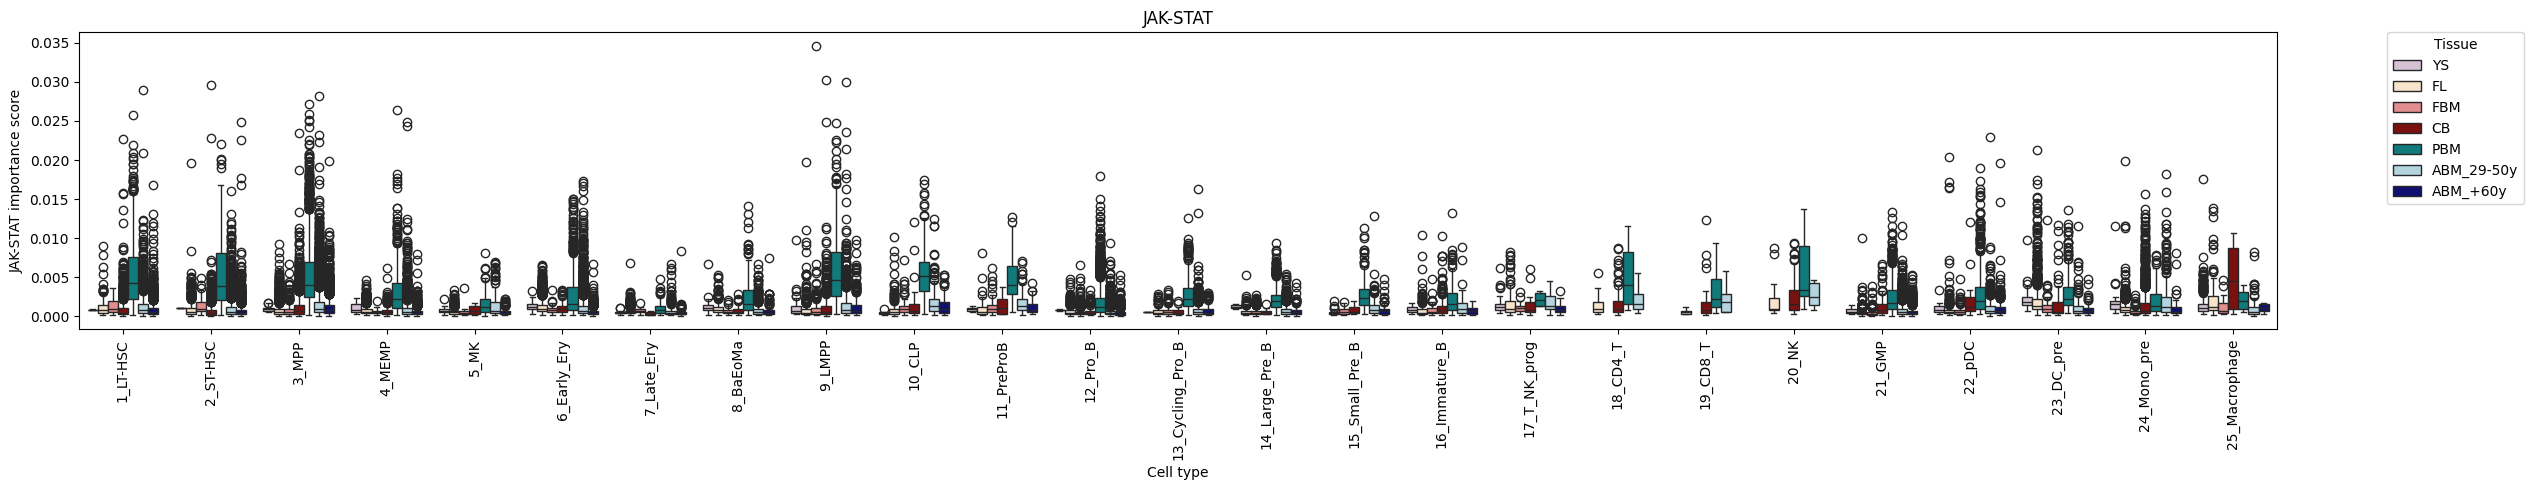

In [30]:
# JAK/STAT: LT-HSC, ST-HSC, MPP, LMPP, CLP, GMP
make_barplot(pert_data, 
             gp = 'JAK-STAT', 
             cell_types = cd34.obs['celltype_v2'].cat.categories, 
             fig_size = (30,5),
             drop_ys = False,
             save = 'jakstat_allcelltypes.pdf'
            )